In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

Data = pd.read_csv('diamonds.csv')
print("Details about data")
print(Data.info())

Details about data
<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  str    
 3   color       53940 non-null  str    
 4   clarity     53940 non-null  str    
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), str(3)
memory usage: 5.1 MB
None


In [2]:
#drop rows with invalid values
Data = Data.drop(Data[Data['x'] == 0].index)
Data = Data.drop(Data[Data['y'] == 1].index)
Data = Data.drop(Data[Data['z'] == 2].index)

In [7]:
# #identify and encode categorical features

# #identify object columns for label encoding
# s = (Data.dtypes == 'object')
# object_cols = list(s[s].index)
# print("Object columns to encode:", object_cols)

# #label encode categorical features
# lb = LabelEncoder()
# for c in object_cols:
#     Data[c] = lb.fit_transform(Data[c])
object_cols = list(Data.select_dtypes(include=['object', 'category']).columns)
print("Object columns to encode:", object_cols)
lb = LabelEncoder()
for c in object_cols:
    Data[c] = lb.fit_transform(Data[c].astype(str))

Object columns to encode: ['cut', 'color', 'clarity']


C:\Users\Admin\AppData\Local\Temp\ipykernel_6552\417252641.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = list(Data.select_dtypes(include=['object', 'category']).columns)


In [8]:
#split features and target

X = Data.drop(['price'], axis=1)
Y = Data['price']

#train test split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=100)

In [9]:
#baseline linear regression model

# # Train Linear Regression model
# lr = LinearRegression()
# lr.fit(X_train, Y_train)
#
# # Predictions
# pred = lr.predict(X_test)
# pred2 =lr.predict(X_train)
#
# # Evaluation
# print("MSE:", mean_squared_error(Y_test, pred))
# print("MAE:", mean_absolute_error(Y_test, pred))
# print("R2 Score:", r2_score(Y_test, pred))
#
# # Plotting
# plt.scatter(Y_train, pred2, color='red', label='Train Data')
# plt.scatter(Y_test, pred, color='green',label='test data')
# plt.xlabel("Actual Price")
# plt.ylabel("Predicted Price")
# plt.title("Linear Regressor - Price Prediction")
# plt.legend()
# plt.show()
#

In [10]:
#training and evaluating lasso regression model

from sklearn import linear_model
from sklearn.linear_model import Lasso

reg1=Lasso(alpha=2)
reg1.fit(X_train,Y_train)
pred1=reg1.predict(X_test)
print("Coefficient Of lasso",reg1.coef_)
print("b0 coefficinet",reg1.intercept_)

print("MSE",mean_squared_error(Y_test,pred1))
print("MAE",mean_absolute_error(Y_test,pred1))
print("R2 score",r2_score(Y_test,pred1))

Coefficient Of lasso [ 6.93199054e-03  1.07567517e+04  7.42521183e+01 -2.64710536e+02
  2.87624994e+02 -1.53358192e+02 -8.87512279e+01 -1.12442495e+03
  1.14366176e+02 -0.00000000e+00]
b0 coefficinet 14913.653659802143
MSE 1827683.6698130555
MAE 873.9681663546181
R2 score 0.8836352170305741


In [11]:
#now train and evaluate ridge regression model

reg2=Ridge(alpha=2)
reg2.fit(X_train,Y_train)
pred1=reg1.predict(X_test)
print("Coefficient Of lasso",reg1.coef_)
print("b0 coefficinet",reg1.intercept_)

print("MSE",mean_squared_error(Y_test,pred1))
print("MAE",mean_absolute_error(Y_test,pred1))
print("R2 score",r2_score(Y_test,pred1))

Coefficient Of lasso [ 6.93199054e-03  1.07567517e+04  7.42521183e+01 -2.64710536e+02
  2.87624994e+02 -1.53358192e+02 -8.87512279e+01 -1.12442495e+03
  1.14366176e+02 -0.00000000e+00]
b0 coefficinet 14913.653659802143
MSE 1827683.6698130555
MAE 873.9681663546181
R2 score 0.8836352170305741


C:\Users\Admin\AppData\Local\Temp\ipykernel_6552\457182270.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


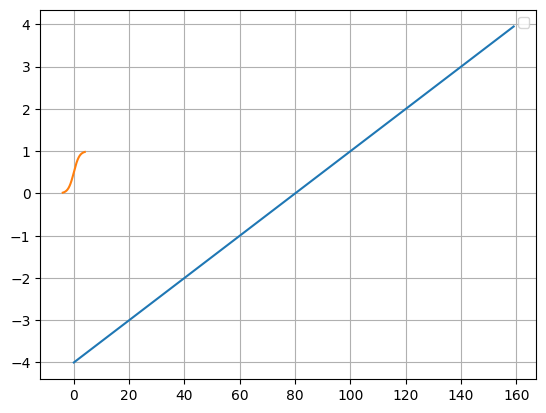

In [12]:
#plot sigmoid activation function 
import numpy as np
import matplotlib.pyplot as plt

z = np.arange(-4,4,0.05)
def sigmoid(z):
    s = 1.0/(1.0 + np.exp(-z))
    return s

plt.plot(z)
output = sigmoid(z)
plt.plot(z,output)
plt.grid()
plt.legend()
plt.show()